# Figure 2 — LinkD-Select

Submitted panels a–g.

Run from top to bottom. All scientific and plotting code is contained in this notebook.

## Data lineage

Packaged source table(s): `data/fig2a.csv`, `data/fig2b.csv`, `data/fig2cd.csv`, `data/fig2e.csv`, `data/fig2f.csv`, `data/fig2g.csv`. They were deterministically extracted by `scripts/reviewer_data/extract_figure_data.py` from retained author analysis tables and manuscript-frozen contracts. The cells below expose every reviewer-side filter, sort, grouping, pivot, coordinate calculation, and plot export. Checksums, schemas, row counts, privacy class, and extraction metadata are recorded in `data/manifest.json`.


In [1]:
from pathlib import Path
from typing import Any
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyBboxPatch, PathPatch
from IPython.display import Image, Markdown, display

# Locate For_Reviewer when Jupyter starts in the repository root,
# For_Reviewer, or For_Reviewer/notebooks.
_candidates = []
for _base in (Path.cwd(), *Path.cwd().parents):
    _candidates.extend((_base, _base / "For_Reviewer"))
ROOT = next(
    (
        _path.resolve()
        for _path in _candidates
        if (_path / "notebooks" / "Data_Preparation.ipynb").is_file() and (_path / "README.md").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate the For_Reviewer folder.")

DATA = Path(os.environ.get("LINKD_REPRO_DATA_DIR", ROOT / "data")).resolve()
STATIC = Path(os.environ.get("LINKD_REPRO_STATIC_DIR", ROOT / "static")).resolve()
MANIFEST = DATA / "manifest.json"
RECOVERY_COMMAND = "Open notebooks/Data_Preparation.ipynb and choose Restart Kernel and Run All."
if not MANIFEST.is_file():
    raise FileNotFoundError(f"Missing {MANIFEST}. {RECOVERY_COMMAND}")

_manifest_entries = json.loads(MANIFEST.read_text(encoding="utf-8"))
_manifest_by_path = {entry["path"]: entry for entry in _manifest_entries}

def verify_input(path):
    """Verify a packaged panel table immediately before loading it."""
    relative = path.relative_to(DATA).as_posix()
    entry = _manifest_by_path.get(relative)
    if entry is None or not path.is_file():
        raise FileNotFoundError(f"Missing packaged input: {path}. {RECOVERY_COMMAND}")
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != entry["sha256"]:
        raise RuntimeError(f"Checksum mismatch for {path}. {RECOVERY_COMMAND}")

PANELS = DATA
ILLUSTRATIONS = STATIC
OUTPUT_ROOT = Path(os.environ.get("LINKD_REPRO_OUTPUT_DIR", ROOT / "outputs")).resolve()
OUTPUT_FIG = OUTPUT_ROOT / "figures"
OUTPUT_DATA = OUTPUT_ROOT / "source_data"
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "pdf.fonttype": 42, "ps.fonttype": 42, "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE = "#4C78A8"; RED = "#E45756"; TEAL = "#2A9D8F"; ORANGE = "#F4A261"; GREY = "#B8B8B8"

def panel_label(ax, value):
    ax.text(-0.15, 1.05, value, transform=ax.transAxes, fontsize=11,
            fontweight="bold", va="top")

def show_static(panel_id, title):
    """Display a submitted static panel and its bundled provenance note."""
    folder = ILLUSTRATIONS / panel_id
    process = folder / "PROCESS.md"
    if not process.is_file():
        raise FileNotFoundError(f"Missing provenance: {process}. {RECOVERY_COMMAND}")
    display(Markdown(f"### {title}\n\n" + process.read_text(encoding="utf-8")))
    assets = sorted([
        *folder.glob("*.png"), *folder.glob("*.jpg"),
        *folder.glob("*.jpeg"), *folder.glob("*.pdf"),
    ])
    if not assets:
        raise FileNotFoundError(f"Missing submitted asset in {folder}. {RECOVERY_COMMAND}")
    raster = next(
        (path for path in assets if path.suffix.lower() in {".png", ".jpg", ".jpeg"}),
        None,
    )
    if raster is not None:
        display(Image(filename=str(raster), width=720))
    else:
        display(Markdown(f"Submitted PDF asset: `{assets[0]}`"))

print("Reviewer package:", ROOT)
print("Panel data:", DATA)
print("Static assets:", STATIC)
print("Outputs:", OUTPUT_ROOT)

ROLE_ORDER = ["Oncogene", "TSG", "Both"]
ROLE_COLORS = {"Oncogene": "#E45756", "TSG": "#4C78A8", "Both": "#54A24B"}
DOCKING_ROLE_COUNTS = {"Oncogene": 154, "TSG": 36, "Both": 33}
DOCKING_RECOVERY = {-8.0: 83.6, -7.0: 92.6, -6.0: 95.3}

Reviewer package: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer
Panel data: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/data
Static assets: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/static
Outputs: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs


## fig2 a — Proteome-wide selectivity landscape

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [2]:
verify_input(PANELS / "fig2a.csv")
data = pd.read_csv(PANELS / "fig2a.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (14981, 5)
columns: ['drug_id', 'drug_name', 'affinity_scaled', 'entropy_scaled', 'selectivity_score']


,drug_id,drug_name,affinity_scaled,entropy_scaled,selectivity_score
0,CHEMBL1000,Cetirizine,0.397263,0.134484,0.235441
1,CHEMBL100014,An-9,0.135360,0.051744,0.058501
2,CHEMBL100109,Chembl100109,0.376331,0.194407,0.153839
3,CHEMBL100116,Pentazocine,0.482391,0.160514,0.149879
4,CHEMBL1002,Levosalbutamol,0.272766,0.155863,0.126627


In [3]:
assert data[["affinity_scaled", "entropy_scaled", "selectivity_score"]].notna().all().all()
assert data[["affinity_scaled", "entropy_scaled", "selectivity_score"]].apply(lambda s: s.between(0, 1).all()).all()
print("PASS — fig2_a manuscript invariants")

PASS — fig2_a manuscript invariants


In [4]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (14981, 5)


,drug_id,drug_name,affinity_scaled,entropy_scaled,selectivity_score
0,CHEMBL1000,Cetirizine,0.397263,0.134484,0.235441
1,CHEMBL100014,An-9,0.135360,0.051744,0.058501
2,CHEMBL100109,Chembl100109,0.376331,0.194407,0.153839
3,CHEMBL100116,Pentazocine,0.482391,0.160514,0.149879
4,CHEMBL1002,Levosalbutamol,0.272766,0.155863,0.126627


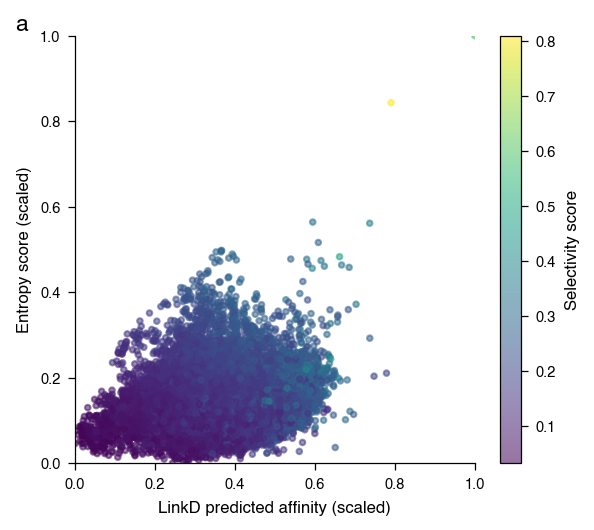

In [5]:
def plot_fig2a(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(4.3, 3.7))
    sc = ax.scatter(data["affinity_scaled"], data["entropy_scaled"],
                    c=data["selectivity_score"], s=7, alpha=.55, cmap="viridis", rasterized=True)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="LinkD predicted affinity (scaled)",
           ylabel="Entropy score (scaled)")
    fig.colorbar(sc, ax=ax).set_label("Selectivity score"); panel_label(ax, "a")
    return fig, data


figure, plotted_source = plot_fig2a(prepared)
display(figure)
plt.close(figure)

In [6]:
pdf_path = OUTPUT_FIG / "fig2_a_selectivity_landscape.pdf"
png_path = OUTPUT_FIG / "fig2_a_selectivity_landscape.png"
csv_path = OUTPUT_DATA / "fig2_a_selectivity_landscape.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig2_a_selectivity_landscape", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Affinity, entropy, and composite selectivity are shown.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_a_selectivity_landscape.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_a_selectivity_landscape.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig2_a_selectivity_landscape.csv
Panel result: Affinity, entropy, and composite selectivity are shown.


## fig2 b — Role-stratified target selectivity

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [7]:
verify_input(PANELS / "fig2b.csv")
data = pd.read_csv(PANELS / "fig2b.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (60, 6)
columns: ['gene', 'role', 'median_selectivity', 'fdr', 'n_on', 'significant']


,gene,role,median_selectivity,fdr,n_on,significant
0,KIT,Oncogene,0.508392,1.225172e-09,35,True
1,ABL1,Oncogene,0.489127,8.383973e-08,27,True
2,EGFR,Oncogene,0.485134,3.921443e-22,61,True
3,GRM3,Oncogene,0.481310,1.127863e-01,3,False
4,FLT3,Oncogene,0.467851,1.744617e-10,42,True


In [8]:
assert set(data["role"]) == set(ROLE_ORDER)
assert data["gene"].nunique() == 60
print("PASS — fig2_b manuscript invariants")

PASS — fig2_b manuscript invariants


In [9]:
prepared = data.sort_values("median_selectivity", ascending=False).copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (60, 6)


,gene,role,median_selectivity,fdr,n_on,significant
0,KIT,Oncogene,0.508392,1.225172e-09,35,True
1,ABL1,Oncogene,0.489127,8.383973e-08,27,True
2,EGFR,Oncogene,0.485134,3.921443e-22,61,True
3,GRM3,Oncogene,0.481310,1.127863e-01,3,False
4,FLT3,Oncogene,0.467851,1.744617e-10,42,True


/var/folders/_0/j8xw5t8j6p3dg7_fq82t36gr0000gp/T/ipykernel_23302/1328847926.py:5: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(x, data["median_selectivity"], c=colors, s=24,


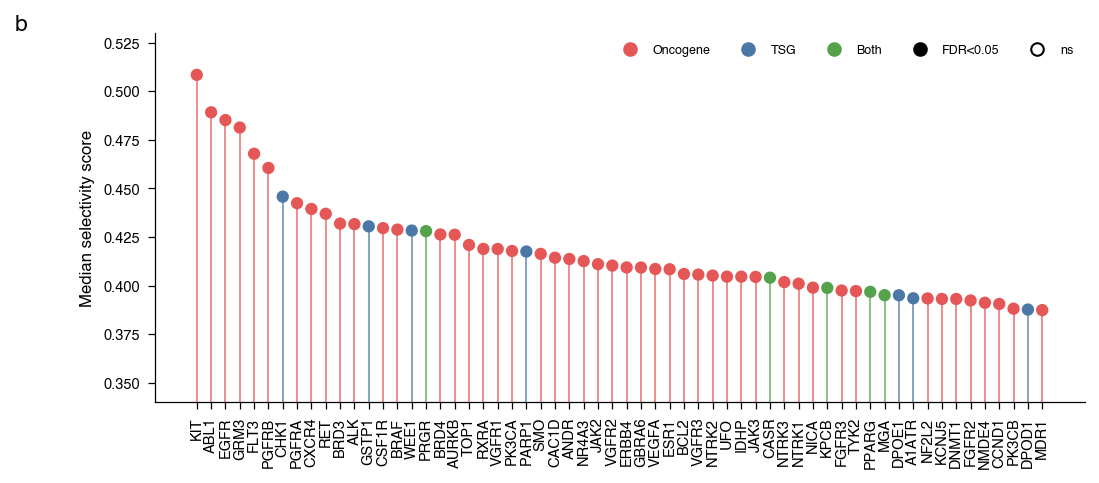

In [10]:
def plot_fig2b(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(8, 3.2)); x = np.arange(len(data))
    colors = data["role"].map(ROLE_COLORS)
    ax.vlines(x, .34, data["median_selectivity"], color=colors, lw=.8, alpha=.8)
    ax.scatter(x, data["median_selectivity"], c=colors, s=24,
               facecolors=np.where(data["significant"], colors, "white"), edgecolors=colors)
    ax.set_xticks(x, data["gene"], rotation=90)
    ax.set_ylim(.34, max(.53, data["median_selectivity"].max() + .01))
    ax.set_ylabel("Median selectivity score")
    handles = [Line2D([], [], marker="o", color="none", markerfacecolor=c,
                      markeredgecolor=c, label=r) for r, c in ROLE_COLORS.items()]
    handles += [Line2D([], [], marker="o", color="none", markerfacecolor="black", label="FDR<0.05"),
                Line2D([], [], marker="o", color="none", markerfacecolor="white",
                       markeredgecolor="black", label="ns")]
    ax.legend(handles=handles, frameon=False, ncol=5, fontsize=6, loc="upper right")
    panel_label(ax, "b"); return fig, data


figure, plotted_source = plot_fig2b(prepared)
display(figure)
plt.close(figure)

In [11]:
pdf_path = OUTPUT_FIG / "fig2_b_target_lollipop.pdf"
png_path = OUTPUT_FIG / "fig2_b_target_lollipop.png"
csv_path = OUTPUT_DATA / "fig2_b_target_lollipop.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig2_b_target_lollipop", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Cancer-gene roles and FDR status are retained.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_b_target_lollipop.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_b_target_lollipop.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig2_b_target_lollipop.csv
Panel result: Cancer-gene roles and FDR status are retained.


## fig2 cd — Top-5% and top-10% recovery

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [12]:
verify_input(PANELS / "fig2cd.csv")
data = pd.read_csv(PANELS / "fig2cd.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (18, 5)
columns: ['cutoff', 'role', 'n', 'ranker', 'percent']


,cutoff,role,n,ranker,percent
0,top-5%,Oncogene,1674,Affinity,25.1
1,top-5%,Oncogene,1674,Selectivity,25.6
2,top-5%,Oncogene,1674,Combined,32.3
3,top-5%,TSG,142,Affinity,6.3
4,top-5%,TSG,142,Selectivity,11.3


In [13]:
assert set(data["cutoff"]) == {"top-5%", "top-10%"}
assert set(data["role"]) == set(ROLE_ORDER)
assert set(data["ranker"]) == {"Affinity", "Selectivity", "Combined"}
expected = {("top-5%", "Oncogene", "Combined"): 32.3, ("top-10%", "Oncogene", "Combined"): 40.6}
got = data.set_index(["cutoff", "role", "ranker"])["percent"]
assert all(np.isclose(got.loc[key], value, atol=0.1) for key, value in expected.items())
print("PASS — fig2_cd manuscript invariants")

PASS — fig2_cd manuscript invariants


In [14]:
prepared = data.copy()
prepared["role"] = pd.Categorical(prepared["role"], ROLE_ORDER, ordered=True)
prepared["ranker"] = pd.Categorical(prepared["ranker"], ["Affinity", "Selectivity", "Combined"], ordered=True)
prepared = prepared.sort_values(["cutoff", "role", "ranker"])
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (18, 5)


,cutoff,role,n,ranker,percent
9,top-10%,Oncogene,1674,Affinity,33.6
10,top-10%,Oncogene,1674,Selectivity,35.5
11,top-10%,Oncogene,1674,Combined,40.6
12,top-10%,TSG,142,Affinity,12.7
13,top-10%,TSG,142,Selectivity,15.5


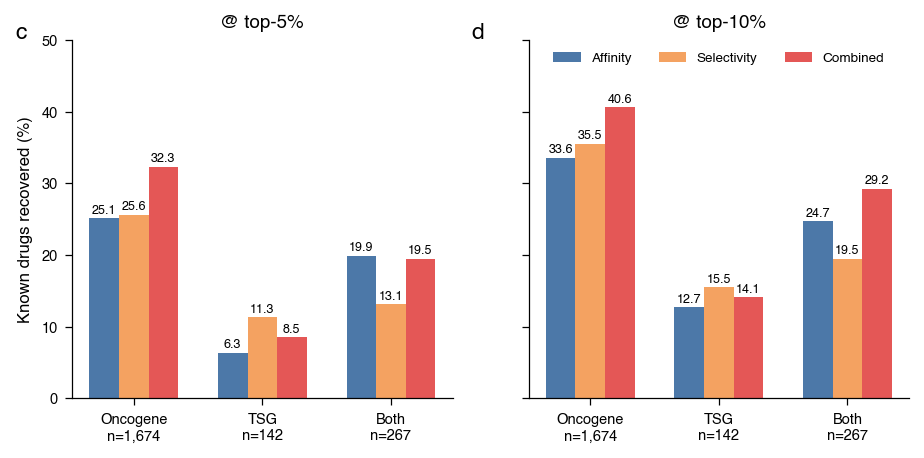

In [15]:
def plot_fig2cd(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1), sharey=True)
    colors = {"Affinity": BLUE, "Selectivity": ORANGE, "Combined": RED}
    for ax, cutoff, letter in zip(axes, ["top-5%", "top-10%"], ["c", "d"]):
        sub = data[data["cutoff"] == cutoff]; x = np.arange(3); width = .23
        for i, ranker in enumerate(colors):
            vals = sub[sub["ranker"] == ranker].set_index("role").reindex(ROLE_ORDER)
            bars = ax.bar(x + (i - 1) * width, vals["percent"], width, color=colors[ranker], label=ranker)
            ax.bar_label(bars, fmt="%.1f", fontsize=6, padding=1)
        ax.set_xticks(x, [f"{r}\nn={int(sub[sub['role'] == r]['n'].iloc[0]):,}" for r in ROLE_ORDER])
        ax.set_ylim(0, 50); ax.set_title(f"@ {cutoff}"); panel_label(ax, letter)
    axes[0].set_ylabel("Known drugs recovered (%)")
    axes[1].legend(frameon=False, fontsize=6.5, ncol=3, loc="upper center")
    return fig, data


figure, plotted_source = plot_fig2cd(prepared)
display(figure)
plt.close(figure)

In [16]:
pdf_path = OUTPUT_FIG / "fig2_cd_recovery.pdf"
png_path = OUTPUT_FIG / "fig2_cd_recovery.png"
csv_path = OUTPUT_DATA / "fig2_cd_recovery.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig2_cd_recovery", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Submitted recovery percentages are reproduced.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_cd_recovery.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_cd_recovery.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig2_cd_recovery.csv
Panel result: Submitted recovery percentages are reproduced.


## fig2 e — EGFR and JAK1 drug profiles

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [17]:
verify_input(PANELS / "fig2e.csv")
data = pd.read_csv(PANELS / "fig2e.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (10, 8)
columns: ['gene', 'drug_name', 'status', 'affinity', 'entropy', 'gap', 'selectivity_ratio', 'selectivity_score']


,gene,drug_name,status,affinity,entropy,gap,selectivity_ratio,selectivity_score
0,EGFR,Canertinib,On,0.780173,0.482933,1.0,1.0,0.646452
1,EGFR,Gefitinib,On,0.750095,0.473816,1.0,1.0,0.622900
2,EGFR,Erlotinib,On,0.755568,0.460701,1.0,1.0,0.620420
3,EGFR,Mifanertinib,Off,0.660665,0.190439,1.0,1.0,0.531614
4,EGFR,Afatinib,On,0.615261,0.127932,1.0,1.0,0.503757


In [18]:
assert set(data["gene"]) == {"EGFR", "JAK1"}
assert (data.groupby("gene").size() == 5).all()
print("PASS — fig2_e manuscript invariants")

PASS — fig2_e manuscript invariants


In [19]:
prepared = data.sort_values(["gene", "selectivity_score"], ascending=[True, False]).copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (10, 8)


,gene,drug_name,status,affinity,entropy,gap,selectivity_ratio,selectivity_score
0,EGFR,Canertinib,On,0.780173,0.482933,1.0,1.0,0.646452
1,EGFR,Gefitinib,On,0.750095,0.473816,1.0,1.0,0.622900
2,EGFR,Erlotinib,On,0.755568,0.460701,1.0,1.0,0.620420
3,EGFR,Mifanertinib,Off,0.660665,0.190439,1.0,1.0,0.531614
4,EGFR,Afatinib,On,0.615261,0.127932,1.0,1.0,0.503757


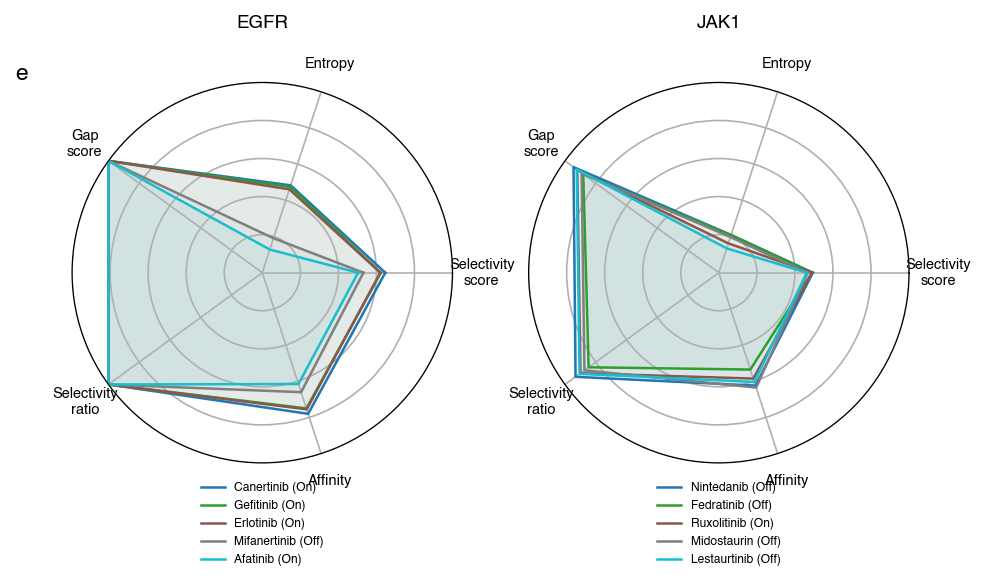

In [20]:
def plot_fig2e(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    metrics = ["selectivity_score", "entropy", "gap", "selectivity_ratio", "affinity"]
    labels = ["Selectivity\nscore", "Entropy", "Gap\nscore", "Selectivity\nratio", "Affinity"]
    angles = np.r_[np.linspace(0, 2*np.pi, len(metrics), endpoint=False), 0]
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.6), subplot_kw={"projection": "polar"})
    for ax, gene in zip(axes, ["EGFR", "JAK1"]):
        for color, (_, row) in zip(plt.cm.tab10(np.linspace(0, 1, 5)), data[data["gene"] == gene].iterrows()):
            values = row[metrics].to_numpy(float); values = np.r_[values, values[0]]
            ax.plot(angles, values, color=color, lw=1.2, label=f"{row['drug_name']} ({row['status']})")
            ax.fill(angles, values, color=color, alpha=.05)
        ax.set_xticks(angles[:-1], labels); ax.set_ylim(0, 1); ax.set_yticklabels([])
        ax.set_title(gene, pad=14, fontweight="bold")
        ax.legend(frameon=False, fontsize=5.8, loc="lower center", bbox_to_anchor=(.5, -.30))
    panel_label(axes[0], "e"); return fig, data


figure, plotted_source = plot_fig2e(prepared)
display(figure)
plt.close(figure)

In [21]:
pdf_path = OUTPUT_FIG / "fig2_e_radar.pdf"
png_path = OUTPUT_FIG / "fig2_e_radar.png"
csv_path = OUTPUT_DATA / "fig2_e_radar.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig2_e_radar", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Five complete drug profiles are shown for each target.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_e_radar.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_e_radar.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig2_e_radar.csv
Panel result: Five complete drug profiles are shown for each target.


## fig2 f — Role-stratified docking distributions

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [22]:
verify_input(PANELS / "fig2f.csv")
data = pd.read_csv(PANELS / "fig2f.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (55534, 6)
columns: ['gene', 'drug_id', 'role', 'target_status', 'docking_score', 'Rank_Select']


,gene,drug_id,role,target_status,docking_score,Rank_Select
0,CDK4,CHEMBL445813,Oncogene,On-Target,-8.8,1
1,CDK4,CHEMBL428690,Oncogene,On-Target,-9.8,2
2,CDK4,CHEMBL384304,Oncogene,On-Target,-8.6,3
3,CDK4,CHEMBL198644,Oncogene,Off-Target,-9.6,4
4,CDK4,CHEMBL5314801,Oncogene,Off-Target,-5.0,7


In [23]:
assert data.groupby("role")["gene"].nunique().to_dict() == DOCKING_ROLE_COUNTS
assert set(data["target_status"]) == {"On-Target", "Off-Target"}
print("PASS — fig2_f manuscript invariants")

PASS — fig2_f manuscript invariants


In [24]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (55534, 6)


,gene,drug_id,role,target_status,docking_score,Rank_Select
0,CDK4,CHEMBL445813,Oncogene,On-Target,-8.8,1
1,CDK4,CHEMBL428690,Oncogene,On-Target,-9.8,2
2,CDK4,CHEMBL384304,Oncogene,On-Target,-8.6,3
3,CDK4,CHEMBL198644,Oncogene,Off-Target,-9.6,4
4,CDK4,CHEMBL5314801,Oncogene,Off-Target,-5.0,7


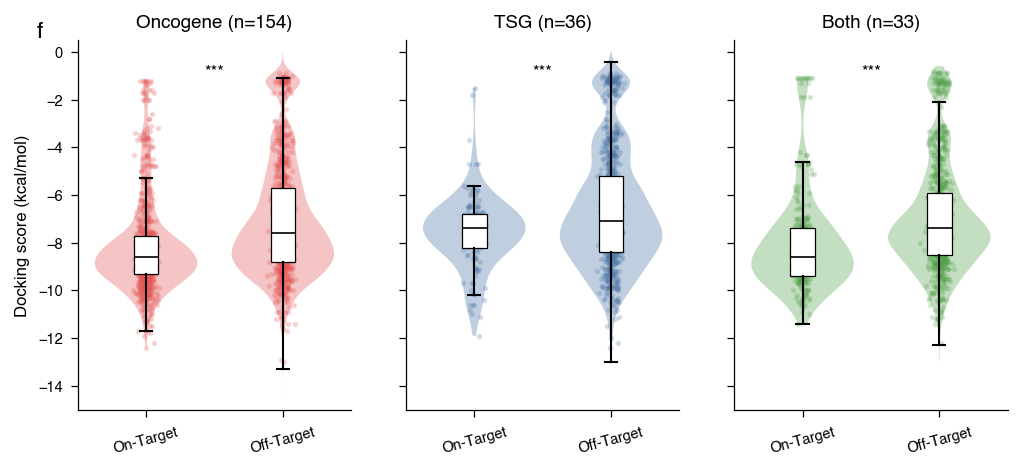

In [25]:
def plot_fig2f(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, axes = plt.subplots(1, 3, figsize=(8, 3.2), sharey=True)
    rng = np.random.default_rng(20260727)
    for ax, role in zip(axes, ROLE_ORDER):
        sub = data[data["role"] == role]
        for status, pos in {"On-Target": 0, "Off-Target": 1}.items():
            vals = sub[sub["target_status"] == status]["docking_score"].to_numpy()
            violin = ax.violinplot(vals, positions=[pos], widths=.75, showextrema=False)
            for body in violin["bodies"]:
                body.set_facecolor(ROLE_COLORS[role]); body.set_alpha(.35)
            sample = vals if len(vals) <= 800 else rng.choice(vals, 800, replace=False)
            ax.scatter(pos + rng.normal(0, .035, len(sample)), sample, s=3,
                       color=ROLE_COLORS[role], alpha=.18, rasterized=True)
            ax.boxplot(vals, positions=[pos], widths=.18, showfliers=False, patch_artist=True,
                       boxprops={"facecolor": "white", "linewidth": .6},
                       medianprops={"color": "black", "linewidth": .8})
        ax.set_xticks([0, 1], ["On-Target", "Off-Target"], rotation=15)
        ax.set_title(f"{role} (n={DOCKING_ROLE_COUNTS[role]})"); ax.text(.5, -1, "***", ha="center")
    axes[0].set_ylabel("Docking score (kcal/mol)"); axes[0].set_ylim(-15, .5)
    panel_label(axes[0], "f"); return fig, data


figure, plotted_source = plot_fig2f(prepared)
display(figure)
plt.close(figure)

In [26]:
pdf_path = OUTPUT_FIG / "fig2_f_docking.pdf"
png_path = OUTPUT_FIG / "fig2_f_docking.png"
csv_path = OUTPUT_DATA / "fig2_f_docking.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig2_f_docking", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: All submitted on/off-target distributions are included.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_f_docking.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_f_docking.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig2_f_docking.csv
Panel result: All submitted on/off-target distributions are included.


## fig2 g — Docking cutoff recovery

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [27]:
verify_input(PANELS / "fig2g.csv")
data = pd.read_csv(PANELS / "fig2g.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (57, 2)
columns: ['cutoff', 'percent_recovered']


,cutoff,percent_recovered
0,-12.4,0.335570
1,-12.2,0.671141
2,-12.1,1.006711
3,-11.9,1.342282
4,-11.7,1.677852


In [28]:
for cutoff, expected in DOCKING_RECOVERY.items():
    nearest = data.iloc[(data["cutoff"] - cutoff).abs().argsort()[:1]]
    assert np.isclose(float(nearest["percent_recovered"].iloc[0]), expected, atol=0.1)
print("PASS — fig2_g manuscript invariants")

PASS — fig2_g manuscript invariants


In [29]:
prepared = data.copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (57, 2)


,cutoff,percent_recovered
0,-12.4,0.335570
1,-12.2,0.671141
2,-12.1,1.006711
3,-11.9,1.342282
4,-11.7,1.677852


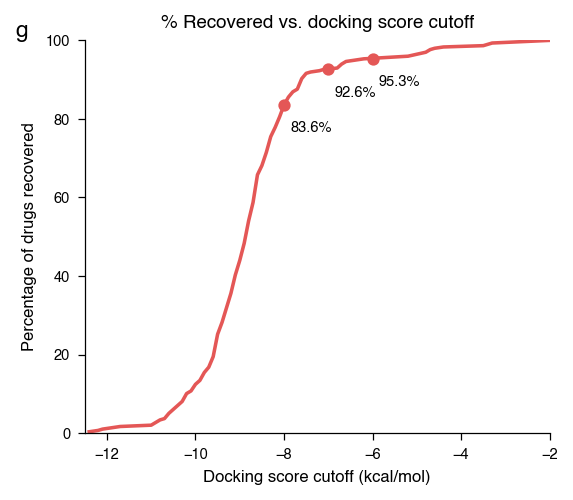

In [30]:
def plot_fig2g(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    fig, ax = plt.subplots(figsize=(4, 3.4))
    ax.plot(data["cutoff"], data["percent_recovered"], color=RED, lw=1.7)
    for cutoff, value in DOCKING_RECOVERY.items():
        ax.scatter([cutoff], [value], color=RED, s=24, zorder=3)
        ax.annotate(f"{value:.1f}%", (cutoff, value), xytext=(3, -13), textcoords="offset points", fontsize=7)
    ax.set(xlim=(-12.5, -2), ylim=(0, 100), xlabel="Docking score cutoff (kcal/mol)",
           ylabel="Percentage of drugs recovered", title="% Recovered vs. docking score cutoff")
    panel_label(ax, "g"); return fig, data


figure, plotted_source = plot_fig2g(prepared)
display(figure)
plt.close(figure)

In [31]:
pdf_path = OUTPUT_FIG / "fig2_g_docking_recovery.pdf"
png_path = OUTPUT_FIG / "fig2_g_docking_recovery.png"
csv_path = OUTPUT_DATA / "fig2_g_docking_recovery.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "fig2_g_docking_recovery", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Recovery is 83.6%, 92.6%, and 95.3% at the submitted cutoffs.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_g_docking_recovery.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/fig2_g_docking_recovery.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/fig2_g_docking_recovery.csv
Panel result: Recovery is 83.6%, 92.6%, and 95.3% at the submitted cutoffs.


## Complete

All assigned panels were displayed inline and exported as PDF, PNG, and source CSV where computational.